In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

import src.config
from src.feature_engineering import MODEL_COLUMNS

PROCESSED_DIR = Path("..") / "data" / "processed"
PHASE = "train"  # always train for EDA
MODEL_DATASET_PATH = PROCESSED_DIR / PHASE / "model_dataset.csv"

plt.rcParams['figure.dpi'] = 100

FEATURE_COLS = [c for c in MODEL_COLUMNS if c not in ["ticker", "label", "bdfr"]]
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Feature columns (18): ['days_from_report', 'fcf', 'netinc', 'revenue', 'sector', 'marketcap', 'netinc_ratio_total', 'fcf_ratio_total', 'netinc_ratio_sector', 'fcf_ratio_sector', 'netinc_prev_1', 'fcf_prev_1', 'ep_diff_from_total', 'ep_sector_diff_total', 'fcfp_diff_from_total', 'fcfp_sector_diff_total', 'ep_fcfp_add_sub_sector', 'current_60_d_r']


# EDA — Processed Data (model_dataset)
Exploration of `data/processed/train/model_dataset.csv` — the final modeling table after all feature engineering.

Sections:
1. Feature distributions
2. Feature–return rank correlations (IC)
3. Feature correlation heatmap
4. Sector analysis
5. Label over time
6. Feature stability (rolling IC)
7. Cross-sectional spread
8. Autocorrelation

In [2]:
if not MODEL_DATASET_PATH.exists():
    raise FileNotFoundError(
        f"model_dataset not found at {MODEL_DATASET_PATH}.\n"
        "Run: python scripts/data_preprocessing.py"
    )

df = pd.read_csv(MODEL_DATASET_PATH, parse_dates=["date"])
df = df.sort_values(["date", "ticker"]).reset_index(drop=True)
print(f"Loaded: {len(df):,} rows | {df['ticker'].nunique():,} tickers | "
      f"{df['date'].min().date()} - {df['date'].max().date()}")
print(f"Columns: {list(df.columns)}")

Loaded: 73,156 rows | 725 tickers | 1998-03-30 - 2011-12-30
Columns: ['date', 'ticker', 'label', 'days_from_report', 'bdfr', 'fcf', 'netinc', 'revenue', 'sector', 'marketcap', 'netinc_ratio_total', 'fcf_ratio_total', 'netinc_ratio_sector', 'fcf_ratio_sector', 'netinc_prev_1', 'fcf_prev_1', 'ep_diff_from_total', 'ep_sector_diff_total', 'fcfp_diff_from_total', 'fcfp_sector_diff_total', 'ep_fcfp_add_sub_sector', 'current_60_d_r']


## 1. Feature Distributions

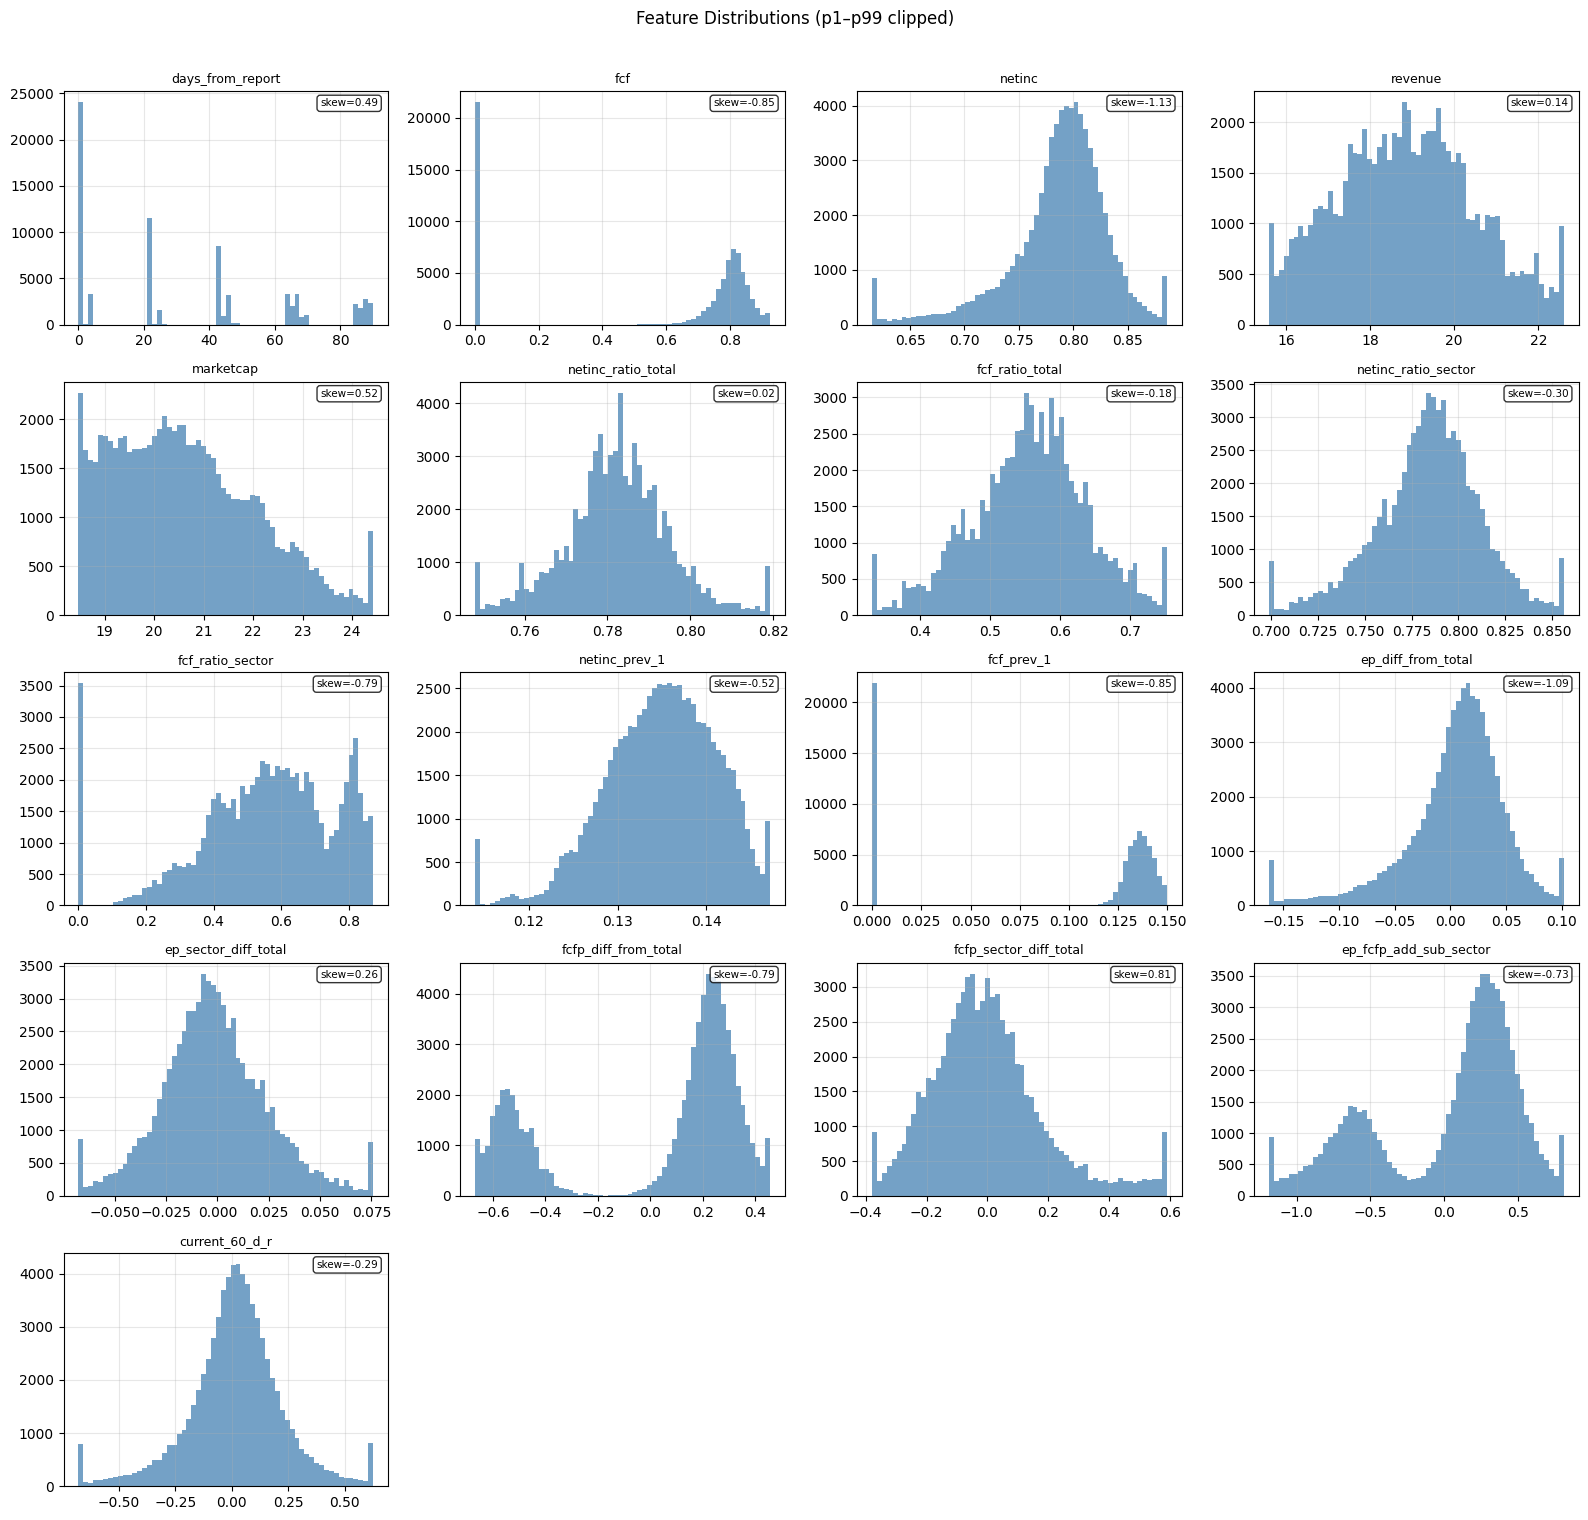

In [3]:
plot_features = [c for c in FEATURE_COLS if c != "sector" and c in df.columns]
n_cols = 4
n_rows = int(np.ceil(len(plot_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, plot_features):
    vals = df[col].dropna()
    clipped = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
    ax.hist(clipped, bins=60, color="steelblue", alpha=0.75, edgecolor="none")
    ax.set_title(col, fontsize=9)
    skew = float(clipped.skew())
    ax.text(0.97, 0.97, f"skew={skew:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    ax.grid(alpha=0.3)

for ax in axes[len(plot_features):]:
    ax.set_visible(False)

plt.suptitle("Feature Distributions (p1–p99 clipped)", y=1.01)
plt.tight_layout()
plt.show()

## 2. Feature–Return Rank Correlations (IC)

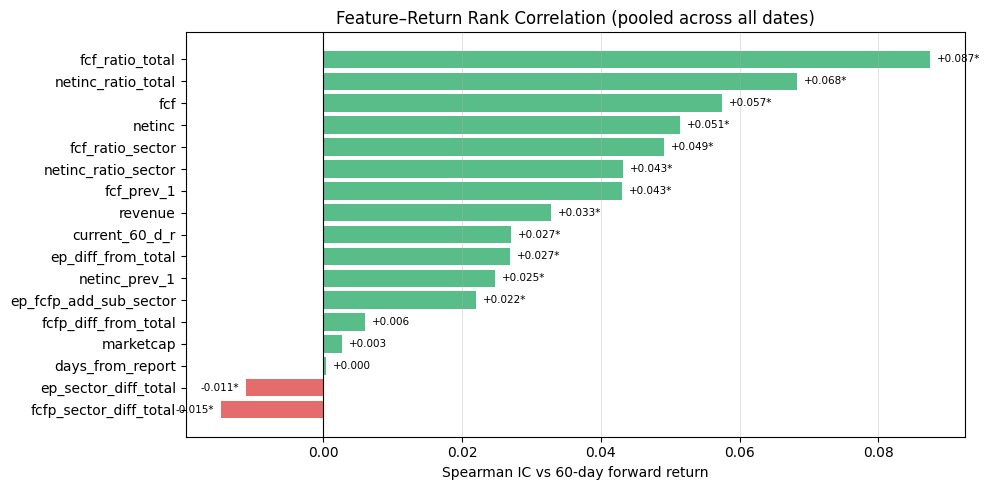

* = p < 0.05


In [4]:
numeric_features = [c for c in FEATURE_COLS if c != "sector" and c in df.columns]
ic_results = []

for feat in numeric_features:
    sub = df[[feat, "label"]].dropna()
    if len(sub) < 30:
        continue
    ic, pval = spearmanr(sub[feat], sub["label"])
    ic_results.append({"feature": feat, "IC": ic, "p_value": pval})

ic_df = pd.DataFrame(ic_results).sort_values("IC", ascending=False)

colors = ["#3BB273" if v > 0 else "#E05252" for v in ic_df["IC"]]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(ic_df["feature"][::-1], ic_df["IC"][::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Spearman IC vs 60-day forward return")
ax.set_title("Feature–Return Rank Correlation (pooled across all dates)")
ax.grid(axis="x", alpha=0.35)
for i, row in enumerate(ic_df.iloc[::-1].itertuples()):
    sig = "*" if row.p_value < 0.05 else ""
    ax.text(row.IC + (0.001 if row.IC >= 0 else -0.001),
            i, f"{row.IC:+.3f}{sig}", va="center",
            ha="left" if row.IC >= 0 else "right", fontsize=7.5)
plt.tight_layout()
plt.show()
print("* = p < 0.05")

## 3. Feature Correlation Heatmap

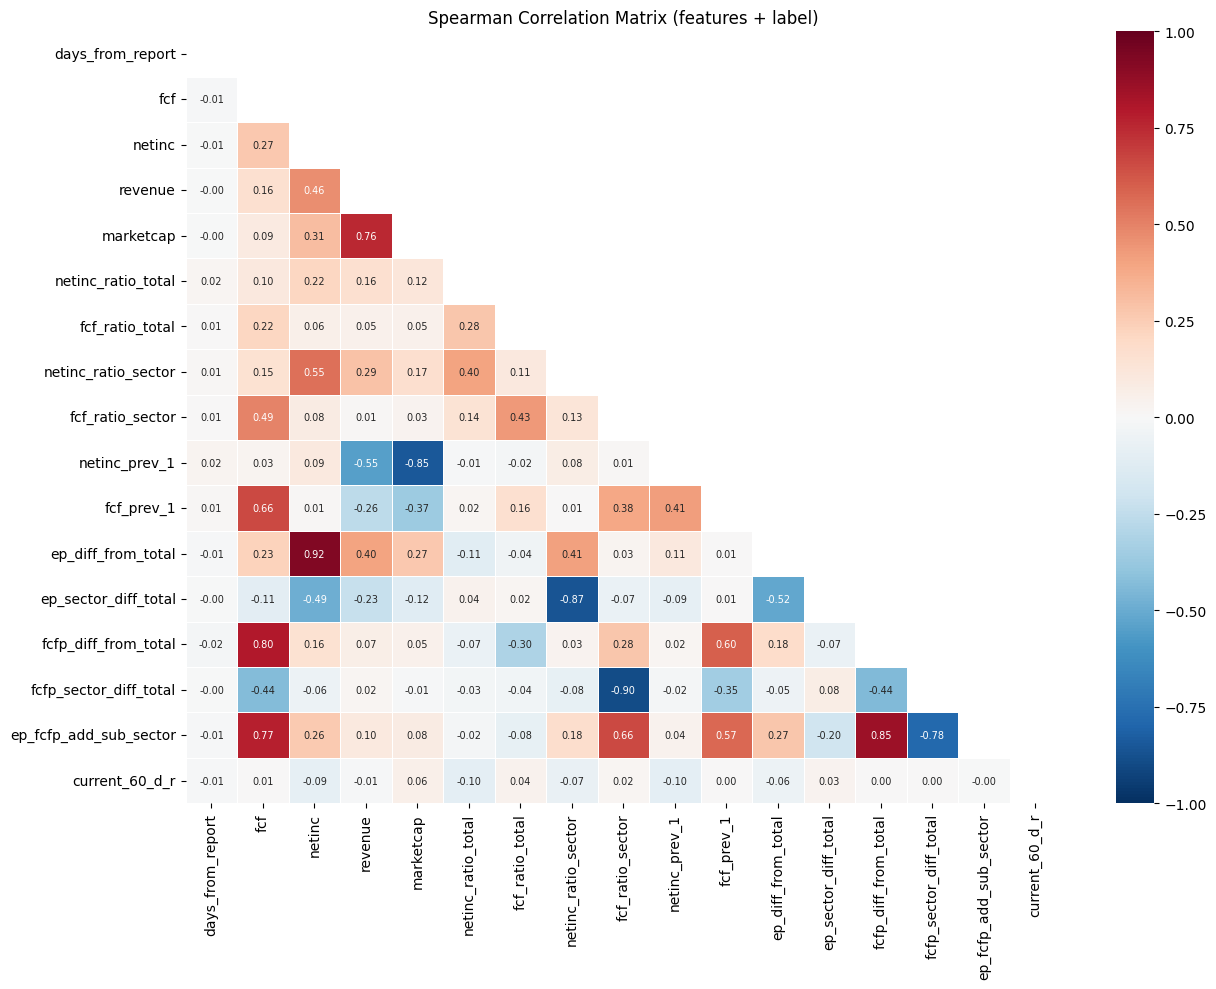

In [5]:
corr_cols = [c for c in numeric_features if c in df.columns]
corr_matrix = df[corr_cols].dropna().sample(min(50000, len(df)), random_state=42).corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={"size": 7},
)
ax.set_title("Spearman Correlation Matrix (features + label)")
plt.tight_layout()
plt.show()

## 4. Sector Analysis

## 5. Label Over Time

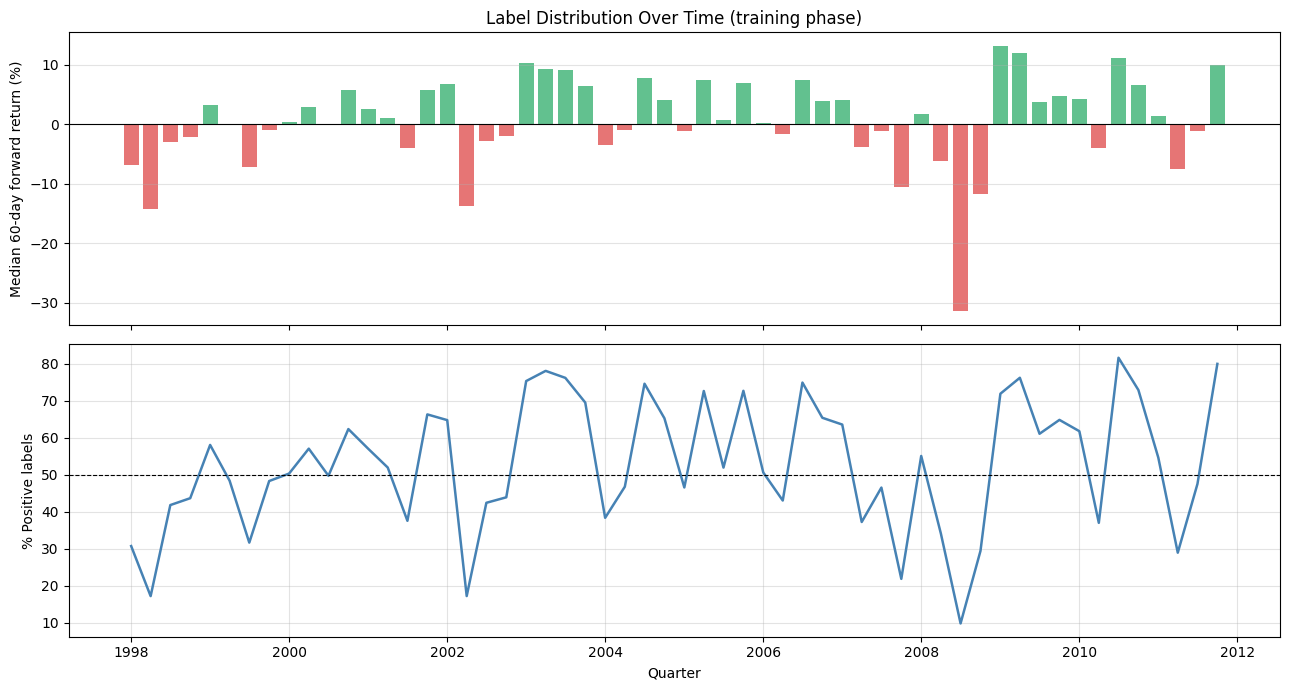

In [7]:
df["quarter"] = df["date"].dt.to_period("Q").dt.to_timestamp()
label_by_q = df.groupby("quarter")["label"].agg(["median", "mean", lambda x: (x > 0).mean() * 100])
label_by_q.columns = ["median", "mean", "pct_positive"]
label_by_q = label_by_q.reset_index()

# Convert log-label back to percent for display
label_by_q["median_pct"] = (np.exp(label_by_q["median"]) - 1) * 100
label_by_q["mean_pct"]   = (np.exp(label_by_q["mean"])   - 1) * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].bar(label_by_q["quarter"], label_by_q["median_pct"],
             color=["#3BB273" if v > 0 else "#E05252" for v in label_by_q["median_pct"]],
             alpha=0.8, width=70)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylabel("Median 60-day forward return (%)")
axes[0].set_title("Label Distribution Over Time (training phase)")
axes[0].grid(axis="y", alpha=0.35)

axes[1].plot(label_by_q["quarter"], label_by_q["pct_positive"],
              color="steelblue", linewidth=1.8)
axes[1].axhline(50, color="black", lw=0.8, ls="--")
axes[1].set_ylabel("% Positive labels")
axes[1].set_xlabel("Quarter")
axes[1].grid(alpha=0.35)

plt.tight_layout()
plt.show()

## 6. Feature Stability — Rolling IC Over Time

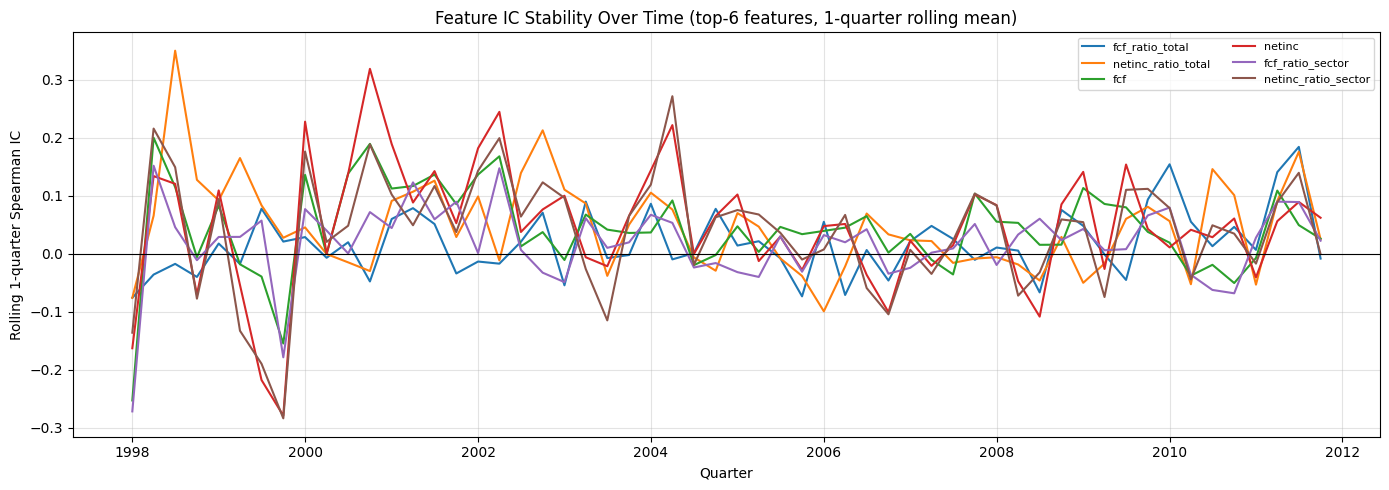

In [14]:
# Compute Spearman IC per feature per quarter, then rolling-mean
ROLLING_WINDOW = 1  # quarters
top_features_for_stability = ic_df["feature"].head(6).tolist()

# Per-quarter IC
quarterly_ic = []
for q, grp in df.groupby("quarter"):
    for feat in top_features_for_stability:
        sub = grp[[feat, "label"]].dropna()
        if len(sub) < 10:
            continue
        ic, _ = spearmanr(sub[feat], sub["label"])
        quarterly_ic.append({"quarter": q, "feature": feat, "IC": ic})

ic_time_df = pd.DataFrame(quarterly_ic)
ic_pivot = ic_time_df.pivot(index="quarter", columns="feature", values="IC")
ic_rolling = ic_pivot.rolling(ROLLING_WINDOW, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
for feat in top_features_for_stability:
    if feat in ic_rolling.columns:
        ax.plot(ic_rolling.index, ic_rolling[feat], label=feat, linewidth=1.5)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Quarter")
ax.set_ylabel(f"Rolling {ROLLING_WINDOW}-quarter Spearman IC")
ax.set_title(f"Feature IC Stability Over Time (top-6 features, {ROLLING_WINDOW}-quarter rolling mean)")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.show()

## 7. Cross-Sectional Spread (Signal Richness)

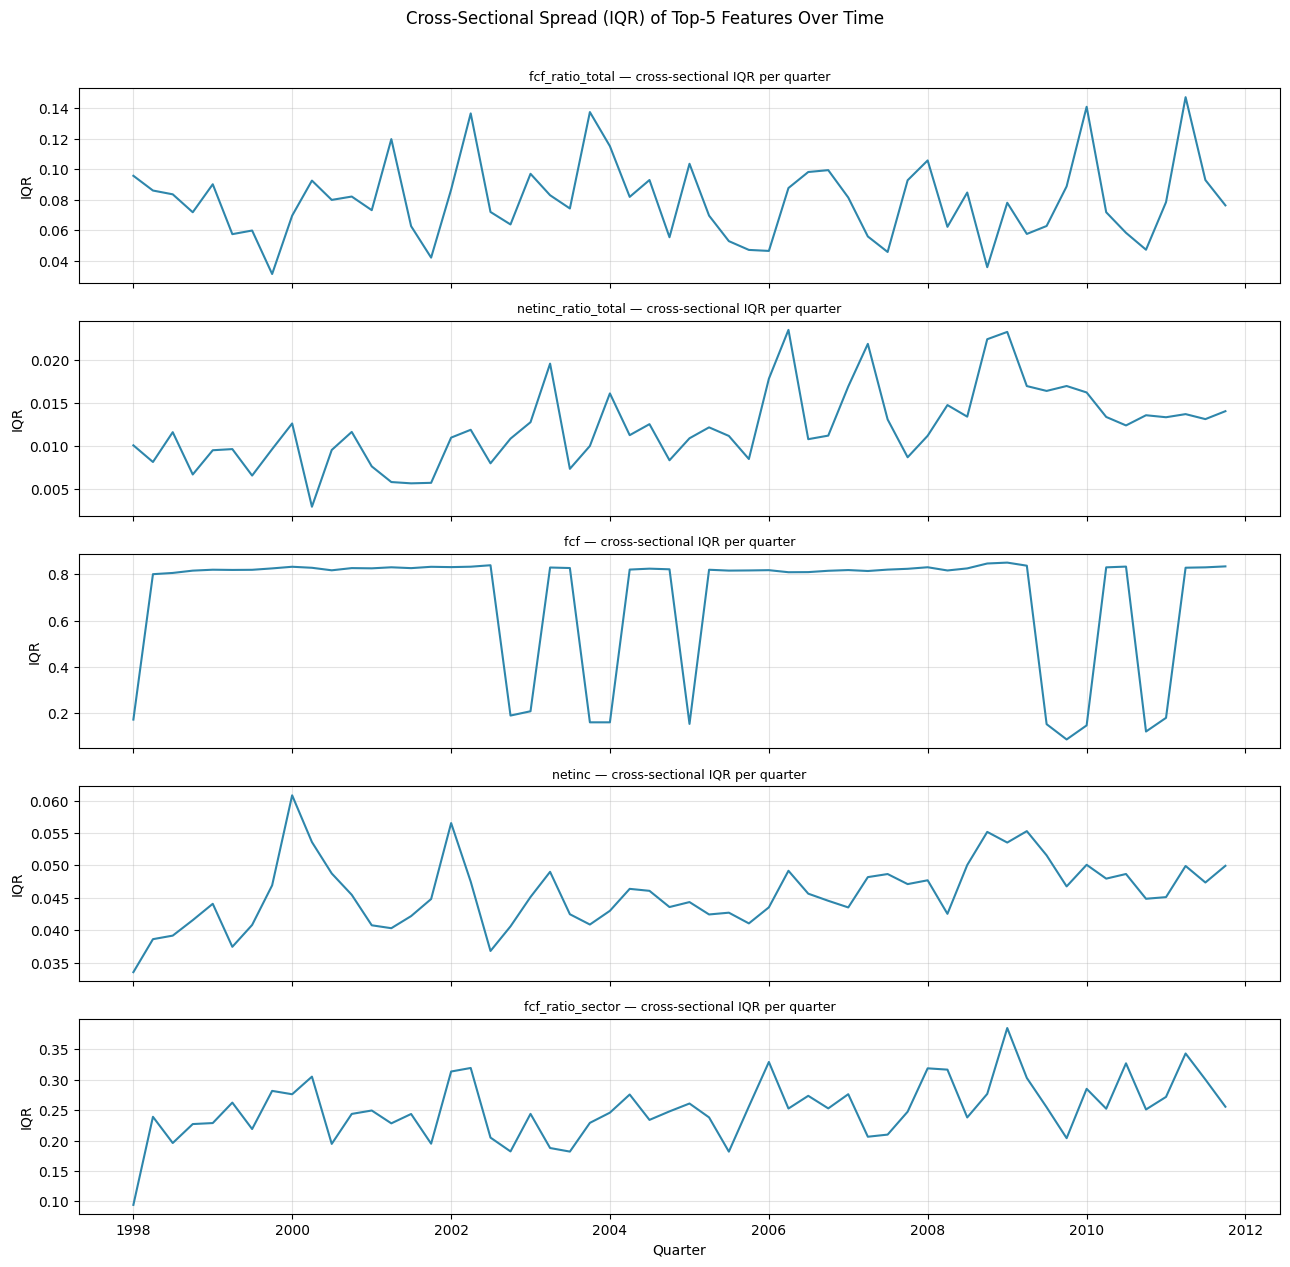

In [15]:
top_features_iqr = ic_df["feature"].head(5).tolist()
iqr_by_q = df.groupby("quarter")[top_features_iqr].apply(
    lambda g: g.quantile(0.75) - g.quantile(0.25)
).reset_index()

fig, axes = plt.subplots(len(top_features_iqr), 1, figsize=(13, 2.5 * len(top_features_iqr)), sharex=True)
if len(top_features_iqr) == 1:
    axes = [axes]

for ax, feat in zip(axes, top_features_iqr):
    ax.plot(iqr_by_q["quarter"], iqr_by_q[feat], linewidth=1.5, color="#2E86AB")
    ax.set_ylabel("IQR")
    ax.set_title(f"{feat} — cross-sectional IQR per quarter", fontsize=9)
    ax.grid(alpha=0.35)

axes[-1].set_xlabel("Quarter")
plt.suptitle("Cross-Sectional Spread (IQR) of Top-5 Features Over Time", y=1.01)
plt.tight_layout()
plt.show()

## 8. Autocorrelation of Label and Top-3 Features

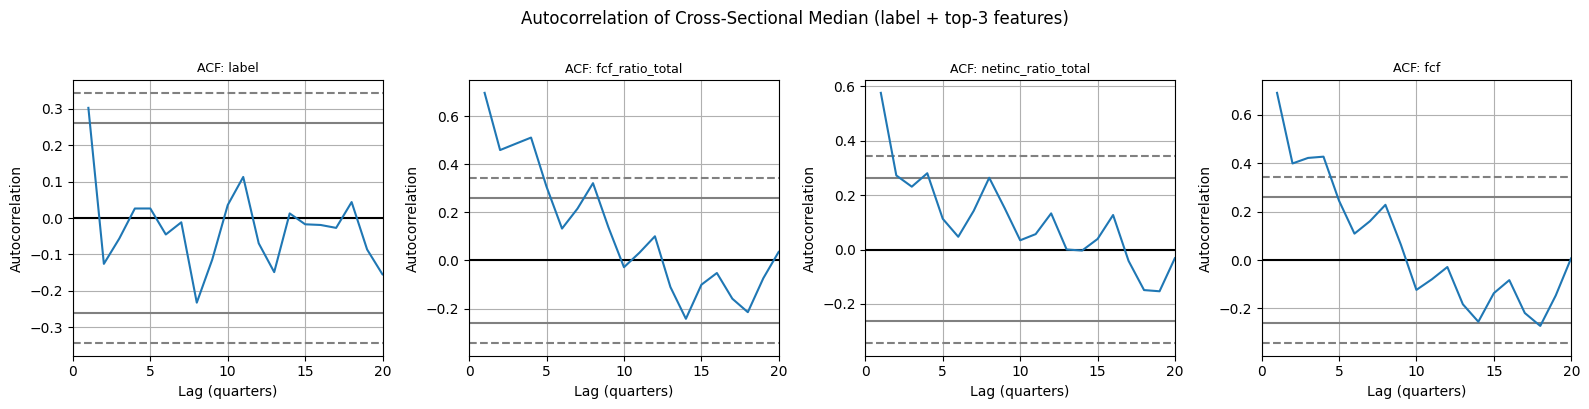

In [16]:
from pandas.plotting import autocorrelation_plot

top3_acf = ["label"] + ic_df["feature"].head(3).tolist()
top3_acf = [c for c in top3_acf if c in df.columns]

# Use median cross-sectional value per quarter as the time series
cs_median = df.groupby("quarter")[top3_acf].median()

fig, axes = plt.subplots(1, len(top3_acf), figsize=(16, 4))
if len(top3_acf) == 1:
    axes = [axes]

for ax, col in zip(axes, top3_acf):
    autocorrelation_plot(cs_median[col].dropna(), ax=ax)
    ax.set_title(f"ACF: {col}", fontsize=9)
    ax.set_xlabel("Lag (quarters)")
    ax.set_xlim(0, 20)

plt.suptitle("Autocorrelation of Cross-Sectional Median (label + top-3 features)", y=1.01)
plt.tight_layout()
plt.show()